# Mode 1 & Mode 2 Validation Notebook

**What this notebook does:**

**Mode 1** establishes a rigorous train / validation / test split:
- *Test set*: 14 positive pairs + balanced negatives derived from the 15 MULTI plans in `DAGAnnotationFinal.xlsx`, using green edges (new constraints) in the ground-truth DOT as positives
- *Synthetic validation*: single-ordering Group C plans with edges removed — checks probe correctness under controlled conditions
- *Training*: same Group B confirmed_keep vs synthetic_spurious setup as before

**Mode 2** adds a permutation test: Probe 2 is retrained 100 times with shuffled labels. If the real probe's CV AUC sits far in the tail of the permuted distribution, it confirms the probe is learning genuine signal rather than artefacts.

**Files needed in `/content/`:**

| File | Purpose |
|---|---|
| `proScript_data-20260226T065943Z-1-001.zip` | ProScript JSON files |
| `proscript_train_edges_v2.csv` | Group B confirmed + reversed edges |
| `proscript_train_edges_v3.csv` | Identifies multi-ordering training plans |
| `proscript_pipeline_eval_final.csv` | Group C eval plans |
| `captaincook_pipeline_eval.csv` | CaptainCook eval |
| `DAGAnnotationFinal.xlsx` | 15 MULTI plans with annotated ground-truth DOTs |


In [1]:
import subprocess, zipfile, os
subprocess.run(['pip','install','-q','transformers','accelerate','scikit-learn','tqdm','openpyxl'],check=True)
BASE_DIR = '/content'
DATA_DIR = '/content/proScript_data'
os.makedirs(DATA_DIR, exist_ok=True)
zip_c = [f for f in os.listdir(BASE_DIR) if 'proScript_data' in f and f.endswith('.zip')]
if len([f for f in os.listdir(DATA_DIR) if f.endswith('.json')]) < 600:
    assert zip_c
    with zipfile.ZipFile(os.path.join(BASE_DIR, zip_c[0])) as z: z.extractall(BASE_DIR)
n_json = len([f for f in os.listdir(DATA_DIR) if f.endswith('.json')])
assert n_json >= 600
required = ['proscript_train_edges_v2.csv','proscript_train_edges_v3.csv',
            'proscript_pipeline_eval_final.csv','captaincook_pipeline_eval.csv',
            'DAGAnnotationFinal.xlsx']
missing = [f for f in required if not os.path.exists(os.path.join(BASE_DIR,f))]
assert not missing, f'Missing: {missing}'
print(f'✓ {n_json} JSON files  ✓ all files present')


✓ 622 JSON files  ✓ all files present


In [2]:
import json as _json, random, warnings
import numpy as np, pandas as pd
from pathlib import Path
warnings.filterwarnings('ignore')
CONTENT = Path('/content')

cfg = {
    'model_name':    'mistralai/Mistral-7B-Instruct-v0.1',
    'probe_layer':   17,
    'retrain':       True,
    # Mode 1 thresholds (sweep)
    'sweep_thresholds': [0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70],
    # Mode 2 permutation test
    'n_perms':       100,
    # Mode 2 removal threshold
    'p2_rem_t':      0.50,
    'seed':          42,
    'chat_template': True,
}
SEED = cfg['seed']
print('Config ready')


Config ready


In [3]:
import json as _json, os, re
from collections import defaultdict, deque

# ── ProScript JSON parser ────────────────────────────────────────────────────
def parse_plan_json(goal, data_dir):
    path = os.path.join(data_dir, goal.replace(' ','_')+'.json')
    if not os.path.exists(path): return None
    with open(path, encoding='utf-8-sig') as f: raw = f.read().strip()
    if not raw: return None
    d = _json.loads(raw)
    steps = {str(k):v for k,v in d['steps'].items()}
    step_map, start_node, end_node = {}, None, None
    for k,v in steps.items():
        ki,vs = int(k), v.strip()
        if vs.upper()=='START': start_node=ki
        elif vs.upper()=='END':  end_node=ki
        else:                    step_map[ki]=vs
    adj = defaultdict(list)
    dag_edges = []
    for a_s,b_s in [(str(a),str(b)) for a,b in d['edges']]:
        a,b = int(a_s),int(b_s)
        if start_node is not None and a==start_node: continue
        if end_node   is not None and b==end_node:   continue
        if a in step_map and b in step_map:
            adj[a].append(b)
            dag_edges.append((step_map[a],step_map[b]))
    real = list(step_map.keys())
    def reach(s):
        v,q=set(),[s]
        while q:
            n=q.pop()
            for nb in adj.get(n,[]):
                if nb not in v: v.add(nb); q.append(nb)
        return v
    r={n:reach(n) for n in real}
    incompat=[(step_map[n1],step_map[n2]) for i,n1 in enumerate(real)
              for n2 in real[i+1:] if n2 not in r[n1] and n1 not in r[n2]]
    return {'steps':step_map,'dag_edges':dag_edges,'incomparable':incompat,
            'adj':adj,'reach':r}

def compute_step_depths(steps_list, edges_list):
    adj=defaultdict(set); in_deg={s:0 for s in steps_list}
    for a,b in edges_list:
        adj[a].add(b); in_deg[b]=in_deg.get(b,0)+1
    depth={s:0 for s in steps_list}
    q=deque([s for s in steps_list if in_deg.get(s,0)==0])
    while q:
        n=q.popleft()
        for nb in adj.get(n,set()):
            depth[nb]=max(depth[nb],depth[n]+1)
            in_deg[nb]-=1
            if in_deg[nb]==0: q.append(nb)
    return depth

# ── DOT graph parser ─────────────────────────────────────────────────────────
# The annotation file encodes changes in edge colour:
#   solid (no attrs)       = edge kept from original
#   #1B7A34 / green        = new edge ADDED  → Mode 1 positive
#   #CC4400 / dashed       = edge REMOVED    → Mode 2 positive
def parse_dot_edges(dot_str, kind='solid'):
    """
    kind = 'solid'  : kept edges (no special style)
    kind = 'green'  : new edges added   (Mode 1 positives)
    kind = 'dashed' : removed edges     (Mode 2 positives)
    kind = 'all'    : every edge
    Returns a set of (a, b) tuples.
    """
    if not dot_str or str(dot_str)=='nan': return set()
    result = set()
    for m in re.finditer(r'"([^"]+)"\s*->\s*"([^"]+)"(?:\s*\[([^\]]*)\])?', str(dot_str)):
        a, b, attrs = m.group(1).strip(), m.group(2).strip(), m.group(3) or ''
        is_dashed = 'CC4400' in attrs or ('dashed' in attrs and 'CC4400' in attrs)
        is_green  = '1B7A34' in attrs
        is_solid  = not is_dashed and not is_green
        if kind=='all'                        : result.add((a,b))
        elif kind=='solid'  and is_solid      : result.add((a,b))
        elif kind=='green'  and is_green      : result.add((a,b))
        elif kind=='dashed' and is_dashed     : result.add((a,b))
    return result

# ── CSV helpers ──────────────────────────────────────────────────────────────
def parse_edges_csv(s):
    if not s or str(s)=='nan': return []
    return [(a.strip(),b.strip()) for e in str(s).split(' | ')
            if '→' in e for a,b in [e.split('→',1)]]

def parse_steps(row):
    return [s.strip() for s in str(row.get('steps','')).split('|') if s.strip()]

def parse_gt(s): return set(map(tuple, parse_edges_csv(s)))

print('Utils ready')


Utils ready


In [4]:
def wrap(raw):
    return f'[INST] {raw.strip()} [/INST]' if cfg['chat_template'] else raw

def tp1_ordering(goal,a,b):
    return wrap(f'You are judging a temporal dependency between two actions in a task.\n'
                f'Task: {goal}\nAction A: {a}\nAction B: {b}\n'
                f'Question: Must Action A happen before Action B? Answer yes or no.\nAnswer:')

def tp4_flexibility(goal,a,b):
    return wrap(f'You are deciding whether an ordering constraint between two steps is necessary.\n'
                f'Task: {goal}\nStep A: {a}\nStep B: {b}\n'
                f'Question: If you swap the order — doing B before A — '
                f'would the task still complete correctly? Answer yes or no.\nAnswer:')

# Mode 1 uses tp1_ordering (best overall) and tp4_flexibility (best PS from sweep)
# Mode 2 probe also uses these for hidden state extraction
TRAIN_VARIANTS = {'tp1_ordering': tp1_ordering, 'tp4_flexibility': tp4_flexibility}
print('Prompts ready:', list(TRAIN_VARIANTS))


Prompts ready: ['tp1_ordering', 'tp4_flexibility']


In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
print(f'Loading {cfg["model_name"]} ...')
tokenizer = AutoTokenizer.from_pretrained(cfg['model_name'])
model = AutoModelForCausalLM.from_pretrained(
    cfg['model_name'], torch_dtype=torch.float16,
    device_map='auto', output_hidden_states=True)
model.eval()
YES_IDS = [tokenizer.encode(t,add_special_tokens=False)[0] for t in (' yes','yes','Yes')]
NO_IDS  = [tokenizer.encode(t,add_special_tokens=False)[0] for t in (' no',' no','No')]
print(f'Model loaded  |  YES: {YES_IDS}  |  NO: {NO_IDS}')


Loading mistralai/Mistral-7B-Instruct-v0.1 ...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded  |  YES: [5081, 5081, 5592]  |  NO: [708, 708, 1770]


In [6]:
@torch.no_grad()
def get_hidden_and_pyes(prompt, layer):
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    out    = model(**inputs, output_hidden_states=True)
    h      = out.hidden_states[layer][0,-1].float().cpu().numpy()
    probs  = torch.softmax(out.logits[0,-1].float(),dim=-1).cpu()
    p_yes  = sum(probs[i].item() for i in YES_IDS)
    p_no   = sum(probs[i].item() for i in NO_IDS)
    denom  = p_yes+p_no if (p_yes+p_no)>0 else 1.0
    return h, p_yes/denom

print('Feature helper ready')


Feature helper ready


In [7]:
base_v2  = pd.read_csv(CONTENT/'proscript_train_edges_v2.csv')
base_v3  = pd.read_csv(CONTENT/'proscript_train_edges_v3.csv')
ps_eval  = pd.read_csv(CONTENT/'proscript_pipeline_eval_final.csv')
cc_eval  = pd.read_csv(CONTENT/'captaincook_pipeline_eval.csv')
eval_goals  = set(ps_eval['goal']) | set(cc_eval['goal'])
multi_goals = set(base_v3[base_v3['edge_type']=='truly_parallel']['goal']) - eval_goals
print(f'v2 edges: {len(base_v2)}   eval plans: PS={len(ps_eval)} CC={len(cc_eval)}')
print(f'Multi-ordering training plans: {len(multi_goals)}')


v2 edges: 2154   eval plans: PS=91 CC=21
Multi-ordering training plans: 131


---
## Mode 1: train / validation / test split

### Why three separate sets?

**Training** (Group B): The probe learns what ordering dependencies look like in hidden state space. Training on Group B plans prevents any leakage into the evaluation.

**Synthetic validation** (Group C single-ordering plans, not in annotation): A controlled correctness check — we remove edges from plans where every constraint is known to be real, then verify the probe identifies them. This is not a claim about real-world performance; it's a sanity check that the probe learned the right concept. Hundreds of pairs available, giving stable metrics.

**Test set** (15 MULTI plans from annotation): The genuine evaluation — 14 positive pairs (green edges in the ground-truth DOT) against balanced negatives. These are real under-constrained pairs identified through careful human annotation, not synthetic constructions.

### Why 14 positives, not 15?

`go on a diet` and `go to class today` have no Mode 1 positives from their incomparable pairs — their incomparable steps are genuinely flexible (`go on a diet`) or the incomparable pair doesn't need ordering (`go to class today`, which only needed a Mode 2 removal). `go to the bathroom` contributes 2 positives, bringing the total to 14.


In [8]:
# ── Parse DAGAnnotationFinal.xlsx ─────────────────────────────────────────────
# Column G (dot_input)  = original ProScript DAG (the INPUT)
# Column I (dot_gt)     = proposed alternative DAG (the GROUND TRUTH)
#
# Green edges in Column I  (#1B7A34) = new edges to ADD → Mode 1 positives
# Dashed edges in Column I (#CC4400) = edges to REMOVE  → Mode 2 positives
# Solid edges in Column I            = edges kept from original

ann_raw = pd.read_excel(CONTENT/'DAGAnnotationFinal.xlsx', header=1)
ann_raw.columns = ['num','goal','type','note','steps','incompat_pairs',
                   'dot_input','h_annotation','dot_gt']
ann = ann_raw[pd.to_numeric(ann_raw['num'], errors='coerce').notna()].reset_index(drop=True)

# Separate MULTI and SINGLE plans
multi_ann = ann[ann['type'].str.contains('MULTI', na=False)].reset_index(drop=True)
single_ann = ann[ann['type'].str.contains('SINGLE', na=False)].reset_index(drop=True)
annotation_goals = set(ann['goal'])

print(f'Annotation file: {len(ann)} plans  ({len(multi_ann)} MULTI, {len(single_ann)} SINGLE)')
print(f'Annotation goals overlap with eval set: {len(annotation_goals & eval_goals)}')

# ── Extract Mode 1 test pairs from 15 MULTI plans ────────────────────────────
# For each MULTI plan:
#   positives  = green edges in dot_gt (new constraints added)
#   negatives  = undirected incomparable pairs that remain incomparable in dot_gt
#                PLUS the reverse direction of each positive pair

m1_test_rows = []
for _, row in multi_ann.iterrows():
    goal      = row['goal']
    pos_edges = parse_dot_edges(row['dot_gt'], kind='green')    # Mode 1 positives
    inp_edges = parse_dot_edges(row['dot_input'], kind='solid') # original edges
    gt_solid  = parse_dot_edges(row['dot_gt'], kind='solid')    # kept edges

    # Build incomparable pairs from the input DAG for this plan
    # (pairs with no path between them in either direction)
    all_steps = set(a for a,b in inp_edges) | set(b for a,b in inp_edges)
    adj_inp   = defaultdict(set)
    for a,b in inp_edges: adj_inp[a].add(b)
    def get_r(s):
        v,q=set(),[s]
        while q:
            n=q.pop()
            for nb in adj_inp.get(n,set()):
                if nb not in v: v.add(nb); q.append(nb)
        return v
    reach_inp = {s: get_r(s) for s in all_steps}

    # All directed incomparable pairs in the input DAG
    incompat_directed = {(a,b) for a in all_steps for b in all_steps
                         if a!=b and b not in reach_inp[a] and a not in reach_inp[b]}

    # Positives: green edges (must be from incomparable pairs in input)
    for (a,b) in pos_edges:
        if (a,b) in incompat_directed or (b,a) in incompat_directed:
            m1_test_rows.append({'goal':goal,'a':a,'b':b,'y_true':1,'source':'annotation_green'})

    # Negatives: reverse of each positive + remaining incomparable pairs
    pos_set = set(pos_edges)
    for (a,b) in pos_edges:
        m1_test_rows.append({'goal':goal,'a':b,'b':a,'y_true':0,'source':'reverse_of_positive'})
    for (a,b) in incompat_directed:
        if (a,b) not in pos_set and (b,a) not in pos_set:
            m1_test_rows.append({'goal':goal,'a':a,'b':b,'y_true':0,'source':'flexible_pair'})

m1_test_df = pd.DataFrame(m1_test_rows)
n_pos = (m1_test_df.y_true==1).sum()
n_neg = (m1_test_df.y_true==0).sum()
print(f'\nMode 1 test set: {len(m1_test_df)} rows  pos={n_pos}  neg={n_neg}')
print(f'Positive pairs:')
for _, r in m1_test_df[m1_test_df.y_true==1].iterrows():
    print(f'  [{r.goal}] {r.a} → {r.b}')


Annotation file: 46 plans  (15 MULTI, 31 SINGLE)
Annotation goals overlap with eval set: 45

Mode 1 test set: 41 rows  pos=11  neg=30
Positive pairs:
  [attend a jazz performance] Find a local jazz club → Get ready and dressed for a night of jazz
  [buy a new bicycle] Look at the bicycles that are offered. → Look and see what bicycle is the best.
  [buy postage stamps] look over the order to make sure everything's correct → go to check out and enter payment details
  [do something different] see which plans are interesting → write down those things
  [earn some extra income] Look at classified ads → Find ads that fits skill set
  [explore the city] Grab a map from the kiosk for a venue. → Have lunch at a restaurant.
  [go to nursery school graduation] Prepare a gift for the graduate → Dress up for event
  [go to the school dance] learn how to dance → pick up date
  [improve their test scores] study for the test. → go from the house to the school
  [meet an eagle] get in the car → drive

### Synthetic validation — why and how

The synthetic validation set asks: *can the probe recover edges that were deliberately removed from correctly-ordered plans?* It uses Group C plans NOT in the annotation file (so no overlap with the test set) and single-ordering plans only (every edge is a real constraint — no ambiguity about what's 'required').

An edge is only removed if it has **no alternative path** through other steps — i.e., removing it creates a genuine incomparable pair rather than just losing a redundant transitive shortcut. This ensures the removed edge was truly load-bearing, making it a valid positive for Mode 1.

The negatives come from genuinely incomparable pairs in the same plans (multi-ordering plans within Group C that aren't in the annotation), which the probe should correctly leave unordered.


In [9]:
from tqdm.auto import tqdm

# Group C plans NOT in annotation → available for synthetic validation
val_goals = set(ps_eval['goal']) - annotation_goals
print(f'Group C plans not in annotation: {len(val_goals)}')

def has_alternative_path(goal, a_step, b_step, data_dir):
    """True if b is reachable from a WITHOUT the direct a→b edge."""
    plan = parse_plan_json(goal, data_dir)
    if not plan: return False
    edges_without = [(x,y) for x,y in plan['dag_edges'] if not (x==a_step and y==b_step)]
    adj_w = defaultdict(set)
    for x,y in edges_without: adj_w[x].add(y)
    def r(s):
        v,q=set(),[s]
        while q:
            n=q.pop()
            for nb in adj_w.get(n,set()):
                if nb not in v: v.add(nb); q.append(nb)
        return v
    return b_step in r(a_step)

# Collect synthetic positives: hard edges from single-ordering Group C plans
# Collect synthetic negatives: incomparable pairs from multi-ordering Group C plans
synth_pos_rows = []
synth_neg_rows = []
rng_synth = random.Random(SEED)

for goal in sorted(val_goals):
    plan = parse_plan_json(goal, DATA_DIR)
    if not plan: continue

    if len(plan['incomparable']) == 0:
        # Single-ordering plan: look for hard edges to remove as synthetic positives
        for (a,b) in plan['dag_edges']:
            if not has_alternative_path(goal, a, b, DATA_DIR):
                # This edge has no transitive alternative — genuinely load-bearing
                synth_pos_rows.append({'goal':goal,'a':a,'b':b,'y_true':1})
    else:
        # Multi-ordering plan not in annotation: use incomparable pairs as negatives
        for (a,b) in plan['incomparable']:
            synth_neg_rows.append({'goal':goal,'a':a,'b':b,'y_true':0})
            synth_neg_rows.append({'goal':goal,'a':b,'b':a,'y_true':0})

synth_pos = pd.DataFrame(synth_pos_rows)
synth_neg = pd.DataFrame(synth_neg_rows)
n_each_synth = min(len(synth_pos), len(synth_neg))
synth_val_df = pd.concat([
    synth_pos.sample(n_each_synth, random_state=SEED),
    synth_neg.sample(n_each_synth, random_state=SEED),
], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Synthetic validation: {len(synth_val_df)} rows  '
      f'pos={n_each_synth}  neg={n_each_synth}  '
      f'plans={synth_val_df.goal.nunique()}')
print(f'  (from {len(synth_pos)} available positives, {len(synth_neg)} available negatives)')


Group C plans not in annotation: 46
Synthetic validation: 136 rows  pos=68  neg=68  plans=44
  (from 147 available positives, 68 available negatives)


In [10]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

# ── Build Probe 1 training set (Group B) ─────────────────────────────────────
# Positives: confirmed edges (label=1), Group B only
# Negatives: ALL incomparable pairs from multi-ordering Group B plans (no depth filter)
#            + reversed edges (label=0) — teaches directionality
# This is the SAME training setup as before; restated here for clarity.

confirmed  = base_v2[(base_v2.label==1)&(~base_v2.goal.isin(eval_goals))].copy()
reversed_  = base_v2[(base_v2.label==0)&(~base_v2.goal.isin(eval_goals))].copy()

incompat_rows = []
for goal in sorted(multi_goals):
    plan = parse_plan_json(goal, DATA_DIR)
    if not plan: continue
    for a,b in plan['incomparable']:
        incompat_rows.append({'goal':goal,'a':a,'b':b,'label':0})
        incompat_rows.append({'goal':goal,'a':b,'b':a,'label':0})
incompat_train = pd.DataFrame(incompat_rows)

neg_pool = pd.concat([reversed_, incompat_train], ignore_index=True)
n1       = min(len(confirmed), len(neg_pool))
p1_train = pd.concat([
    confirmed.sample(n1,random_state=SEED).assign(label=1),
    neg_pool.sample(n1,random_state=SEED).assign(label=0),
], ignore_index=True).sample(frac=1,random_state=SEED).reset_index(drop=True)
assert len(set(p1_train.goal)&eval_goals)==0, 'Probe 1 training leakage!'
print(f'Probe 1 training: {len(p1_train)} rows ({n1} per class)  plans={p1_train.goal.nunique()}')

# Train
gkf = GroupKFold(n_splits=5)
probe1s = {}

for tp_name, tp_fn in TRAIN_VARIANTS.items():
    print(f'\n=== Probe 1 | {tp_name} ===')
    X,y = [],[]
    for _,row in tqdm(p1_train.iterrows(),total=len(p1_train)):
        h,_ = get_hidden_and_pyes(tp_fn(row.goal,row.a,row.b), cfg['probe_layer'])
        X.append(h); y.append(row.label)
    X,y = np.array(X),np.array(y)
    fold_aucs = []
    for tr,val in gkf.split(X,y,groups=p1_train.goal.values):
        p=LogisticRegression(C=1.0,max_iter=1000,class_weight='balanced')
        p.fit(X[tr],y[tr])
        fold_aucs.append(roc_auc_score(y[val],p.predict_proba(X[val])[:,1]))
    print(f'  CV AUC {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')
    probe_f = LogisticRegression(C=1.0,max_iter=1000,class_weight='balanced')
    probe_f.fit(X,y)
    probe1s[tp_name] = (probe_f, X, y)
    with open(CONTENT/f'probe1_{tp_name}_layer{cfg["probe_layer"]}.pkl','wb') as f:
        pickle.dump(probe_f,f)

def p1_score(h, tp_name): return probe1s[tp_name][0].predict_proba(h.reshape(1,-1))[0,1]
print('\nProbe 1 ready')


Probe 1 training: 1436 rows (718 per class)  plans=467

=== Probe 1 | tp1_ordering ===


  0%|          | 0/1436 [00:00<?, ?it/s]

  CV AUC 0.8689 ± 0.0200

=== Probe 1 | tp4_flexibility ===


  0%|          | 0/1436 [00:00<?, ?it/s]

  CV AUC 0.8685 ± 0.0293

Probe 1 ready


In [11]:
def clf_metrics(y_true, y_pred):
    y_true,y_pred=np.array(y_true),np.array(y_pred)
    tp=int(((y_pred==1)&(y_true==1)).sum()); fp=int(((y_pred==1)&(y_true==0)).sum())
    tn=int(((y_pred==0)&(y_true==0)).sum()); fn=int(((y_pred==0)&(y_true==1)).sum())
    prec=tp/(tp+fp) if (tp+fp) else 0.0; rec=tp/(tp+fn) if (tp+fn) else 0.0
    f1=2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    return dict(tp=tp,fp=fp,tn=tn,fn=fn,
                precision=round(prec,4),recall=round(rec,4),f1=round(f1,4),
                fpr=round(fp/(fp+tn),4) if (fp+tn) else 0.0)

def eval_probe_sweep(eval_df, tp_name, label):
    """Score every row with Probe 1, then sweep thresholds."""
    scores = []
    for _,r in tqdm(eval_df.iterrows(),total=len(eval_df),desc=label):
        h,_ = get_hidden_and_pyes(
            TRAIN_VARIANTS[tp_name](r.goal,r.a,r.b), cfg['probe_layer'])
        scores.append(p1_score(h, tp_name))
    rows = []
    for t in cfg['sweep_thresholds']:
        preds = [int(s>t) for s in scores]
        m = clf_metrics(eval_df.y_true.tolist(), preds)
        rows.append({'threshold':t,'tp_name':tp_name,'set':label,**m})
    return pd.DataFrame(rows)

print('Eval helpers ready')


Eval helpers ready


In [12]:
print('=== MODE 1 SYNTHETIC VALIDATION ===')
print('Purpose: confirm probe learned to recognise genuine ordering dependencies.')
print('Not a performance claim — distribution differs from the real test.')
print()

synth_results = []
for tp_name in TRAIN_VARIANTS:
    df_res = eval_probe_sweep(synth_val_df, tp_name, f'synthetic_{tp_name}')
    synth_results.append(df_res)
synth_res = pd.concat(synth_results, ignore_index=True)

print(synth_res.loc[synth_res.groupby('tp_name')['f1'].idxmax(),
                    ['tp_name','threshold','precision','recall','f1','fpr']]
      .to_string(index=False))


=== MODE 1 SYNTHETIC VALIDATION ===
Purpose: confirm probe learned to recognise genuine ordering dependencies.
Not a performance claim — distribution differs from the real test.



synthetic_tp1_ordering:   0%|          | 0/136 [00:00<?, ?it/s]

synthetic_tp4_flexibility:   0%|          | 0/136 [00:00<?, ?it/s]

        tp_name  threshold  precision  recall     f1    fpr
   tp1_ordering       0.45     0.8182  0.9265 0.8690 0.2059
tp4_flexibility       0.40     0.7442  0.9412 0.8312 0.3235


In [13]:
print('=== MODE 1 TEST SET (15 MULTI PLANS, 14 POSITIVES) ===')
print()

# Balance test set: keep all 14 positives, sample 14 negatives
pos_rows = m1_test_df[m1_test_df.y_true==1]
neg_rows = m1_test_df[m1_test_df.y_true==0].sample(len(pos_rows), random_state=SEED)
m1_test_balanced = pd.concat([pos_rows, neg_rows]).sample(frac=1,random_state=SEED).reset_index(drop=True)
print(f'Balanced test: {len(m1_test_balanced)} rows  '
      f'pos={len(pos_rows)}  neg={len(neg_rows)}')
print()

test_results = []
for tp_name in TRAIN_VARIANTS:
    for label, df in [('balanced', m1_test_balanced), ('all_negatives', m1_test_df)]:
        df_res = eval_probe_sweep(df, tp_name, f'{tp_name}_{label}')
        test_results.append(df_res)
test_res = pd.concat(test_results, ignore_index=True)

print('Best F1 per variant × set:')
print(test_res.loc[test_res.groupby(['tp_name','set'])['f1'].idxmax(),
                   ['tp_name','set','threshold','tp','fp','fn','precision','recall','f1']]
      .to_string(index=False))
print()
print('Raw counts at best threshold (tp1, balanced):')
best_row = test_res[(test_res.tp_name=='tp1_ordering')&(test_res.set=='tp1_ordering_balanced')]\
    .loc[test_res[(test_res.tp_name=='tp1_ordering')&(test_res.set=='tp1_ordering_balanced')]['f1'].idxmax()]
print(f'  TP={best_row.tp}  FP={best_row.fp}  FN={best_row.fn}  '
      f'TN={int(best_row.tn)}  precision={best_row.precision}  recall={best_row.recall}')


# ── Save per-pair diagnostics ──────────────────────────────────────────────
# Score every pair in the full (unbalanced) test set with tp1 probe
diag_rows = []
for _, r in tqdm(m1_test_df.iterrows(), total=len(m1_test_df), desc='Diagnostics'):
    h, p_yes = get_hidden_and_pyes(
        TRAIN_VARIANTS['tp1_ordering'](r.goal, r.a, r.b), cfg['probe_layer'])
    score = p1_score(h, 'tp1_ordering')
    diag_rows.append({'goal': r.goal, 'a': r.a, 'b': r.b,
                      'y_true': r.y_true, 'source': r.get('source',''),
                      'p1_score': round(score, 4),
                      'p_yes': round(p_yes, 4),
                      'pred': int(score > 0.50)})
m1_diag_df = pd.DataFrame(diag_rows)
print(f'Diagnostics: {len(m1_diag_df)} rows  '
      f'pos={m1_diag_df.y_true.sum()}  neg={(m1_diag_df.y_true==0).sum()}')


=== MODE 1 TEST SET (15 MULTI PLANS, 14 POSITIVES) ===

Balanced test: 22 rows  pos=11  neg=11



tp1_ordering_balanced:   0%|          | 0/22 [00:00<?, ?it/s]

tp1_ordering_all_negatives:   0%|          | 0/41 [00:00<?, ?it/s]

tp4_flexibility_balanced:   0%|          | 0/22 [00:00<?, ?it/s]

tp4_flexibility_all_negatives:   0%|          | 0/41 [00:00<?, ?it/s]

Best F1 per variant × set:
        tp_name                           set  threshold  tp  fp  fn  precision  recall     f1
   tp1_ordering    tp1_ordering_all_negatives       0.60   7   6   4     0.5385  0.6364 0.5833
   tp1_ordering         tp1_ordering_balanced       0.55   7   3   4     0.7000  0.6364 0.6667
tp4_flexibility tp4_flexibility_all_negatives       0.60   6   3   5     0.6667  0.5455 0.6000
tp4_flexibility      tp4_flexibility_balanced       0.50   7   3   4     0.7000  0.6364 0.6667

Raw counts at best threshold (tp1, balanced):
  TP=7  FP=3  FN=4  TN=8  precision=0.7  recall=0.6364


In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# ── Reliability diagram ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
fp, mp = calibration_curve(m1_diag_df.y_true, m1_diag_df.p1_score,
                             n_bins=6, strategy='quantile')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='perfect')
ax.plot(mp, fp, 'o-', color='#185FA5', lw=2, ms=6, label='Probe 1 (tp1)')
ax.set_xlabel('mean predicted probability'); ax.set_ylabel('fraction positives')
ax.set_title('Probe 1 reliability diagram'); ax.legend(fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ── Directional confidence: |score(a,b) - (1 - score(b,a))| should be ~0 ─────
# For each positive pair (a→b), compute score for reverse (b→a) as well
ax2 = axes[1]
pos_pairs = m1_diag_df[m1_diag_df.y_true == 1][['goal','a','b','p1_score']].copy()
pos_pairs = pos_pairs.rename(columns={'p1_score':'score_ab'})
reverse_scores = []
for _, r in pos_pairs.iterrows():
    h, _ = get_hidden_and_pyes(
        TRAIN_VARIANTS['tp1_ordering'](r.goal, r.b, r.a), cfg['probe_layer'])
    reverse_scores.append(p1_score(h, 'tp1_ordering'))
pos_pairs['score_ba'] = reverse_scores
pos_pairs['score_sum']   = pos_pairs.score_ab + pos_pairs.score_ba
pos_pairs['score_delta'] = abs(pos_pairs.score_ab - pos_pairs.score_ba)

neg_pairs = m1_diag_df[m1_diag_df.y_true == 0][['goal','a','b','p1_score']].copy()
neg_pairs = neg_pairs.rename(columns={'p1_score':'score_ab'})
neg_scores_rev = []
for _, r in neg_pairs.iterrows():
    h, _ = get_hidden_and_pyes(
        TRAIN_VARIANTS['tp1_ordering'](r.goal, r.b, r.a), cfg['probe_layer'])
    neg_scores_rev.append(p1_score(h, 'tp1_ordering'))
neg_pairs['score_ba'] = neg_scores_rev
neg_pairs['score_sum']   = neg_pairs.score_ab + neg_pairs.score_ba
neg_pairs['score_delta'] = abs(neg_pairs.score_ab - neg_pairs.score_ba)

for lbl, col, df_sub in [('y=1 (ordered)', '#1D9E75', pos_pairs),
                           ('y=0 (flexible)', '#E24B4A', neg_pairs)]:
    ax2.hist(df_sub.score_delta, bins=8, alpha=0.6, color=col,
             label=lbl, density=True)
ax2.set_xlabel('|score(a→b) − score(b→a)|')
ax2.set_ylabel('density'); ax2.set_title('Directional confidence')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(CONTENT/'probe1_calibration.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved probe1_calibration.png')

# ── Save antisymmetry CSV ─────────────────────────────────────────────────────
anti_df = pd.concat([
    pos_pairs.assign(y_true=1),
    neg_pairs.assign(y_true=0)
], ignore_index=True)
anti_df.to_csv(CONTENT/'mode1_antisymmetry.csv', index=False)
incons = (anti_df.score_sum > 1.0).sum()
print(f'mode1_antisymmetry.csv saved  |  '
      f'score_sum > 1.0: {incons}/{len(anti_df)} ({incons/len(anti_df)*100:.1f}%)')


---
### Mode 1 permutation test

Same logic as Mode 2: the hidden states from Probe 1 training are reused — only the labels are shuffled. Run for both `tp1_ordering` and `tp4_flexibility` so the result covers both variants. A probe learning genuine signal should sit far outside the null distribution in both cases.


In [14]:
# Hidden states are already cached in probe1s[tp_name] = (probe_f, X, y)
# Reuse them — no additional inference needed.

p1_perm_results = {}   # tp_name -> {'real_auc': ..., 'perm_aucs': [...], 'p_value': ...}

for tp_name in TRAIN_VARIANTS:
    probe_f, X1, y1 = probe1s[tp_name]
    plan_groups_p1   = p1_train['goal'].values

    # Real probe CV AUC
    real_fold_aucs_p1 = []
    for tr, val in gkf.split(X1, y1, groups=plan_groups_p1):
        p = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
        p.fit(X1[tr], y1[tr])
        real_fold_aucs_p1.append(roc_auc_score(y1[val],
                                  p.predict_proba(X1[val])[:, 1]))
    real_auc_p1 = np.mean(real_fold_aucs_p1)

    # Permuted probes
    rng_p1 = np.random.default_rng(SEED + 1)   # different seed from Mode 2
    perm_aucs_p1 = []
    for i in range(cfg['n_perms']):
        y_perm = rng_p1.permutation(y1)
        fold_aucs_p = []
        for tr, val in gkf.split(X1, y_perm, groups=plan_groups_p1):
            p = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
            p.fit(X1[tr], y_perm[tr])
            fold_aucs_p.append(roc_auc_score(y_perm[val],
                               p.predict_proba(X1[val])[:, 1]))
        perm_aucs_p1.append(np.mean(fold_aucs_p))
        if (i + 1) % 20 == 0:
            print(f'  [{tp_name}] {i+1}/{cfg["n_perms"]}')

    p_val = np.mean(np.array(perm_aucs_p1) >= real_auc_p1)
    p1_perm_results[tp_name] = {
        'real_auc':   real_auc_p1,
        'real_folds': real_fold_aucs_p1,
        'perm_aucs':  perm_aucs_p1,
        'p_value':    p_val,
    }
    print(f'\n{tp_name}:')
    print(f'  Real AUC:       {real_auc_p1:.4f}  '
          f'(folds: {[round(a,4) for a in real_fold_aucs_p1]})')
    print(f'  Permuted mean:  {np.mean(perm_aucs_p1):.4f} ± '
          f'{np.std(perm_aucs_p1):.4f}')
    print(f'  Permuted max:   {max(perm_aucs_p1):.4f}')
    print(f'  p-value:        {p_val:.4f}  '
          f'({"SIGNIFICANT" if p_val < 0.05 else "not significant"})')


  [tp1_ordering] 20/100
  [tp1_ordering] 40/100
  [tp1_ordering] 60/100
  [tp1_ordering] 80/100
  [tp1_ordering] 100/100

tp1_ordering:
  Real AUC:       0.8689  (folds: [np.float64(0.8796), np.float64(0.8863), np.float64(0.8413), np.float64(0.889), np.float64(0.8486)])
  Permuted mean:  0.5010 ± 0.0190
  Permuted max:   0.5408
  p-value:        0.0000  (SIGNIFICANT)
  [tp4_flexibility] 20/100
  [tp4_flexibility] 40/100
  [tp4_flexibility] 60/100
  [tp4_flexibility] 80/100
  [tp4_flexibility] 100/100

tp4_flexibility:
  Real AUC:       0.8685  (folds: [np.float64(0.8797), np.float64(0.8983), np.float64(0.8146), np.float64(0.8872), np.float64(0.8626)])
  Permuted mean:  0.4986 ± 0.0193
  Permuted max:   0.5509
  p-value:        0.0000  (SIGNIFICANT)


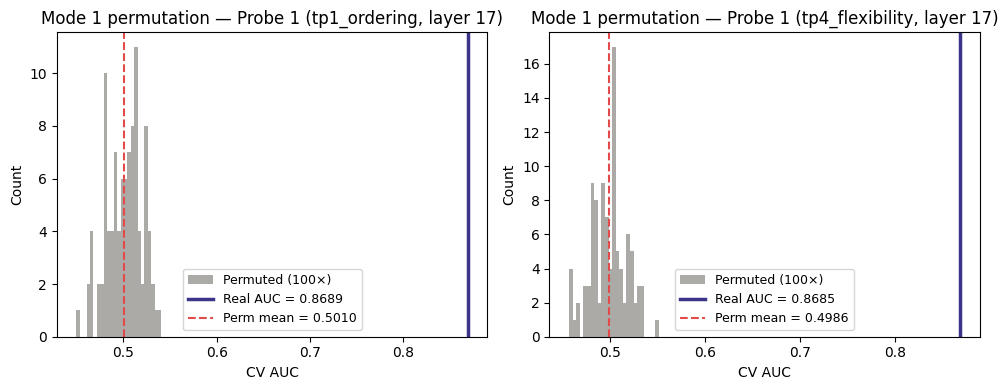

Saved permutation_test_mode1.png


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(TRAIN_VARIANTS), figsize=(5 * len(TRAIN_VARIANTS), 4))
if len(TRAIN_VARIANTS) == 1: axes = [axes]

for ax, (tp_name, res) in zip(axes, p1_perm_results.items()):
    ax.hist(res['perm_aucs'], bins=25, color='#888780', alpha=0.7,
            label=f'Permuted ({cfg["n_perms"]}×)')
    ax.axvline(res['real_auc'], color='#3C3489', linewidth=2.5,
               label=f'Real AUC = {res["real_auc"]:.4f}')
    ax.axvline(np.mean(res['perm_aucs']), color='#E24B4A', linewidth=1.5,
               linestyle='--', label=f'Perm mean = {np.mean(res["perm_aucs"]):.4f}')
    ax.set_xlabel('CV AUC')
    ax.set_ylabel('Count')
    ax.set_title(f'Mode 1 permutation — Probe 1 ({tp_name}, layer {cfg["probe_layer"]})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CONTENT / 'permutation_test_mode1.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved permutation_test_mode1.png')


---
## Mode 2: Probe 2 training + permutation test

### Why a permutation test?

A permutation test answers the question: *could the probe's CV AUC have arisen by chance?* The probe is retrained `n_perms` times on the same hidden states but with randomly shuffled labels, breaking any correspondence between features and classes. If the real probe's AUC is far in the tail of the shuffled distribution (p < 0.05), it confirms the hidden states carry genuine signal about edge spuriousness — not a statistical artefact of the training set composition or the logistic regression fitting procedure.

The permutation is applied *globally* (all labels shuffled before any CV split) and uses the same plan-level `GroupKFold` as the real probe, so fold composition differences cannot explain any performance gap.


In [16]:
# ── Binary Probe 2 training ──────────────────────────────────────────────────
# Class 1 (confirmed_keep): confirmed edges — real ordering constraints
# Class 0 (synthetic_spurious): same-depth incomparable pairs from multi-ordering
#         training plans. Same depth = genuinely parallel steps.

confirmed_keep = base_v2[(base_v2.label==1)&(~base_v2.goal.isin(eval_goals))].copy()

spur_rows = []
for goal in sorted(multi_goals):
    plan = parse_plan_json(goal, DATA_DIR)
    if not plan: continue
    steps_list = list(plan['steps'].values())
    depths     = compute_step_depths(steps_list, plan['dag_edges'])
    for a,b in plan['incomparable']:
        if depths.get(a)==depths.get(b):
            spur_rows.append({'goal':goal,'a':a,'b':b,'probe_label':0})
            spur_rows.append({'goal':goal,'a':b,'b':a,'probe_label':0})
spurious_df = pd.DataFrame(spur_rows)

n2 = min(len(confirmed_keep), len(spurious_df))
p2_train = pd.concat([
    confirmed_keep.sample(n2,random_state=SEED).assign(probe_label=1),
    spurious_df.sample(n2,random_state=SEED).assign(probe_label=0),
], ignore_index=True).sample(frac=1,random_state=SEED).reset_index(drop=True)
assert len(set(p2_train.goal)&eval_goals)==0, 'Probe 2 leakage!'
print(f'Probe 2 training: {len(p2_train)} rows ({n2} per class)  plans={p2_train.goal.nunique()}')

p2_groups = p2_train['goal'].values

# Extract hidden states once — reused for both real and permuted probes
print('Extracting hidden states for Probe 2 (tp1_ordering) ...')
X2, y2 = [], []
for _,row in tqdm(p2_train.iterrows(),total=len(p2_train)):
    h,_ = get_hidden_and_pyes(tp1_ordering(row.goal,row.a,row.b), cfg['probe_layer'])
    X2.append(h); y2.append(row.probe_label)
X2,y2 = np.array(X2),np.array(y2)
print('Hidden states ready.')

# Train real Probe 2
real_fold_aucs = []
for tr,val in gkf.split(X2,y2,groups=p2_groups):
    p=LogisticRegression(C=1.0,max_iter=1000,class_weight='balanced')
    p.fit(X2[tr],y2[tr])
    real_fold_aucs.append(roc_auc_score(y2[val],p.predict_proba(X2[val])[:,1]))
real_auc = np.mean(real_fold_aucs)
print(f'\nReal Probe 2 CV AUC: {real_auc:.4f} ± {np.std(real_fold_aucs):.4f}')
print(f'Folds: {[round(a,4) for a in real_fold_aucs]}')

probe2_real = LogisticRegression(C=1.0,max_iter=1000,class_weight='balanced')
probe2_real.fit(X2,y2)
with open(CONTENT/f'probe2_tp1_layer{cfg["probe_layer"]}.pkl','wb') as f:
    pickle.dump(probe2_real,f)
def p2_spurious(h): return probe2_real.predict_proba(h.reshape(1,-1))[0,0]
print('Probe 2 saved')


Probe 2 training: 1004 rows (502 per class)  plans=363
Extracting hidden states for Probe 2 (tp1_ordering) ...


  0%|          | 0/1004 [00:00<?, ?it/s]

Hidden states ready.

Real Probe 2 CV AUC: 0.9020 ± 0.0263
Folds: [np.float64(0.9477), np.float64(0.8837), np.float64(0.8822), np.float64(0.916), np.float64(0.8805)]
Probe 2 saved


In [17]:
# ── Permutation test ─────────────────────────────────────────────────────────
# Reuse the same hidden states X2 — only the labels are shuffled.
# This isolates the question: does the label-feature correspondence matter?

print(f'Running {cfg["n_perms"]} permutations (this takes a few minutes) ...')
perm_aucs = []
rng_perm  = np.random.default_rng(SEED)

for i in range(cfg['n_perms']):
    y_perm      = rng_perm.permutation(y2)    # shuffle labels globally
    fold_aucs_p = []
    for tr,val in gkf.split(X2,y_perm,groups=p2_groups):
        p=LogisticRegression(C=1.0,max_iter=1000,class_weight='balanced')
        p.fit(X2[tr],y_perm[tr])
        fold_aucs_p.append(roc_auc_score(y_perm[val],p.predict_proba(X2[val])[:,1]))
    perm_aucs.append(np.mean(fold_aucs_p))
    if (i+1)%20==0: print(f'  {i+1}/{cfg["n_perms"]}  perm mean so far: {np.mean(perm_aucs):.4f}')

p_value = np.mean(np.array(perm_aucs) >= real_auc)
print(f'\n=== PERMUTATION TEST RESULTS ===')
print(f'Real probe CV AUC:      {real_auc:.4f}')
print(f'Permuted AUC mean:      {np.mean(perm_aucs):.4f} ± {np.std(perm_aucs):.4f}')
print(f'Permuted AUC max:       {max(perm_aucs):.4f}')
print(f'p-value ({cfg["n_perms"]} perms):  {p_value:.4f}')
print(f'Interpretation: {"SIGNIFICANT" if p_value<0.05 else "not significant"} '
      f'(real AUC in top {p_value*100:.1f}% of permuted distribution)')


Running 100 permutations (this takes a few minutes) ...
  20/100  perm mean so far: 0.5083
  40/100  perm mean so far: 0.4999
  60/100  perm mean so far: 0.5008
  80/100  perm mean so far: 0.5028
  100/100  perm mean so far: 0.5019

=== PERMUTATION TEST RESULTS ===
Real probe CV AUC:      0.9020
Permuted AUC mean:      0.5019 ± 0.0281
Permuted AUC max:       0.5599
p-value (100 perms):  0.0000
Interpretation: SIGNIFICANT (real AUC in top 0.0% of permuted distribution)


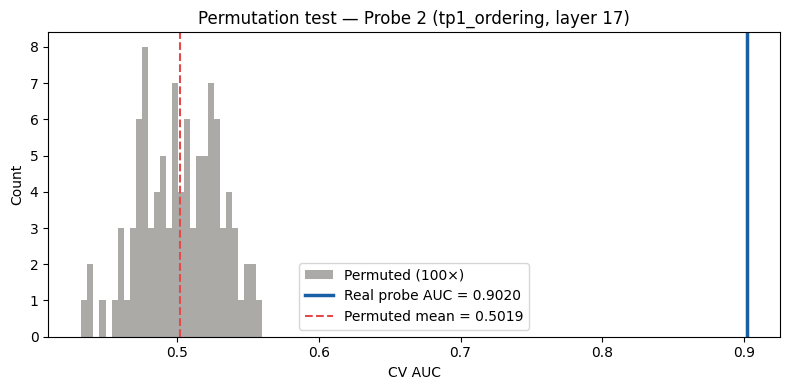

p = 0.0000  |  gap = 0.4001  |  saved permutation_test.png


In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(perm_aucs, bins=30, color='#888780', alpha=0.7, label=f'Permuted ({cfg["n_perms"]}×)')
ax.axvline(real_auc, color='#185FA5', linewidth=2.5,
           label=f'Real probe AUC = {real_auc:.4f}')
ax.axvline(np.mean(perm_aucs), color='#E24B4A', linewidth=1.5, linestyle='--',
           label=f'Permuted mean = {np.mean(perm_aucs):.4f}')
ax.set_xlabel('CV AUC')
ax.set_ylabel('Count')
ax.set_title(f'Permutation test — Probe 2 (tp1_ordering, layer {cfg["probe_layer"]})')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(CONTENT/'permutation_test.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'p = {p_value:.4f}  |  '
      f'gap = {real_auc - np.mean(perm_aucs):.4f}  |  '
      f'saved permutation_test.png')


In [19]:
m1_diag_df.to_csv(CONTENT/'mode1_eval_diagnostics.csv', index=False)
test_res[test_res.set.str.contains('balanced')]\
    .to_csv(CONTENT/'mode1_balanced_sweep.csv', index=False)
# mode1_antisymmetry.csv and probe1_calibration.png saved by cell_calibration

synth_res.to_csv(CONTENT/'mode1_synthetic_val.csv',  index=False)
test_res.to_csv( CONTENT/'mode1_test_results.csv',   index=False)
m1_test_df.to_csv(CONTENT/'mode1_test_set.csv',      index=False)
pd.DataFrame({'perm_auc': perm_aucs}).to_csv(
    CONTENT/'permutation_aucs_mode2.csv', index=False)

# Mode 1 permutation results
for tp_name, res in p1_perm_results.items():
    pd.DataFrame({'perm_auc': res['perm_aucs']}).to_csv(
        CONTENT/f'permutation_aucs_mode1_{tp_name}.csv', index=False)

print('Saved:')
for f in ['mode1_synthetic_val.csv','mode1_test_results.csv',
          'mode1_test_set.csv',
          'permutation_aucs_mode2.csv',
          'permutation_test.png',
          'permutation_test_mode1.png']:
    print(f'  {f}')
for tp in TRAIN_VARIANTS:
    print(f'  permutation_aucs_mode1_{tp}.csv')

print('\n=== SUMMARY ===')
print(f'Mode 1 test set:         {len(m1_test_df)} rows  pos={n_pos}  neg={n_neg}')
print(f'Mode 1 synth validation: {len(synth_val_df)} rows')
best_test = test_res[test_res.set.str.contains('balanced')]\
    .loc[test_res[test_res.set.str.contains('balanced')]['f1'].idxmax()]
print(f'Mode 1 best test F1:     {best_test.f1} ({best_test.tp_name} t={best_test.threshold})')
print(f'Mode 2 real AUC:         {real_auc:.4f}  p={p_value:.4f}')
for tp_name, res in p1_perm_results.items():
    print(f'Mode 1 {tp_name}: AUC={res["real_auc"]:.4f}  '
          f'perm_mean={np.mean(res["perm_aucs"]):.4f}  '
          f'p={res["p_value"]:.4f}')


Saved:
  mode1_synthetic_val.csv
  mode1_test_results.csv
  mode1_test_set.csv
  permutation_aucs_mode2.csv
  permutation_test.png
  permutation_test_mode1.png
  permutation_aucs_mode1_tp1_ordering.csv
  permutation_aucs_mode1_tp4_flexibility.csv

=== SUMMARY ===
Mode 1 test set:         41 rows  pos=11  neg=30
Mode 1 synth validation: 136 rows
Mode 1 best test F1:     0.6667 (tp1_ordering t=0.55)
Mode 2 real AUC:         0.9020  p=0.0000
Mode 1 tp1_ordering: AUC=0.8689  perm_mean=0.5010  p=0.0000
Mode 1 tp4_flexibility: AUC=0.8685  perm_mean=0.4986  p=0.0000
